# Drinking Water System Violation Analysis

## Executive Summary

This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions. Major findings: (1) Non-Transient Non-Community Water Systems (`NTNCWS`) show the largest number of high-rate systems in this dataset, (2) several small systems exhibit very high per-capita rates driven by low population denominators, and (3) county-weighted rates highlight different priorities than raw system counts.

Recommendations: prioritize inspections for systems with high `Violation_Rate` and small populations (investigate data quality and local context), present both per-system and population-weighted county metrics to decision-makers, and collect additional data (inspection dates, violation severity) to enable prioritization models.

---

## Table of Contents
1. **Data Loading & Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Statistical Analysis – Theory & Methodology**
4. **Statistical Analysis – Code & Results**
5. **Statistical Analysis – Interpretation**
6. **Actionable Recommendations & Implementation**
7. **Visualizations**
8. **Conclusions & Next Steps**

In [1]:
import pandas as pd
from typing import TYPE_CHECKING
if TYPE_CHECKING:

    df: pd.DataFrame

df = None
try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    pio.renderers.default = 'notebook'
except Exception:
    print('Plotly not available — to enable interactive plots, run: pip install plotly')
import matplotlib.pyplot as plt

df = pd.read_csv("Drinking_Water_Violations.csv")

rename_map = {
    'PWSName':'System_Name', 'PWSId':'System_ID', 'CountiesServed':'County',
    'PWSTypeCode':'System_Type', 'PrimarySourceCode':'Source_Type',
    'PopulationServedCount':'Population', 'QtrsWithVio':'Violation_Quarters_3yr',
    'Viopaccr':'Violation_Points_5yr', 'Vioremain':'Uncorrected_Violation_Points',
    'Ifea':'Informal_Enforcement_Actions_5yr', 'Feas':'Formal_Enforcement_Actions_5yr',
    'SeriousViolator':'Serious_Violator'
}

existing_renames = {k: v for k, v in rename_map.items() if k in df.columns}
if existing_renames:
    df = df.rename(columns=existing_renames)


for col in ['Population','Violation_Quarters_3yr','Violation_Points_5yr','Uncorrected_Violation_Points']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Validating required columns and computing derived metrics if needed...')
if 'Violation_Rate' not in df.columns:
    if 'Violation_Quarters_3yr' in df.columns and 'Population' in df.columns:
        df['Violation_Rate'] = (df['Violation_Quarters_3yr'] / df['Population']) * 1000
        print('Computed Violation_Rate; NaN count:', int(df['Violation_Rate'].isna().sum()))
    else:
        missing = [c for c in ['Violation_Quarters_3yr','Population'] if c not in df.columns]
        print('Cannot compute Violation_Rate — missing columns:', missing)
else:
    print('Violation_Rate already present')

if 'Violation_Rate' in df.columns and df['Violation_Rate'].isna().any():
    n_missing = int(df['Violation_Rate'].isna().sum())
    print(f'Found {n_missing} rows with NaN Violation_Rate — showing up to 5 examples:')
    display(df.loc[df['Violation_Rate'].isna(), ['System_ID','System_Name','County','Population','Violation_Quarters_3yr']].head())

print(df.dtypes)
{
            "cell_type": "markdown",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "# Executive Summary",
                "\n",
                "This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions. Major findings: (1) Non-Transient Non-Community Water Systems (`NTNCWS`) show the largest number of high-rate systems in this dataset, (2) several small systems exhibit very high per-capita rates driven by low population denominators, and (3) county-weighted rates highlight different priorities than raw system counts.\n",
                "\n",
                "Recommendations: prioritize inspections for systems with high `Violation_Rate` and small populations (investigate data quality and local context), present both per-system and population-weighted county metrics to decision-makers, and collect additional data (inspection dates, violation severity) to enable prioritization models. The notebook includes reproducible cleaning steps, diagnostics for missing data, and interactive plots for exploratory review."
            ]
        },


Plotly not available — to enable interactive plots, run: pip install plotly
Validating required columns and computing derived metrics if needed...
Computed Violation_Rate; NaN count: 0
System_Name                          object
System_ID                            object
StateCode                            object
County                               object
System_Type                          object
Source_Type                          object
Population                            int64
Violation_Quarters_3yr                int64
Serious_Violator                     object
Violation_Points_5yr                  int64
Uncorrected_Violation_Points          int64
Informal_Enforcement_Actions_5yr      int64
Formal_Enforcement_Actions_5yr      float64
Violation_Rate                      float64
dtype: object
Validating required columns and computing derived metrics if needed...
Computed Violation_Rate; NaN count: 0
System_Name                          object
System_ID                       

({'cell_type': 'markdown',
  'metadata': {'language': 'markdown'},
  'source': ['# Executive Summary',
   '\n',
   'This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions. Major findings: (1) Non-Transient Non-Community Water Systems (`NTNCWS`) show the largest number of high-rate systems in this dataset, (2) several small systems exhibit very high per-capita rates driven by low population denominators, and (3) county-weighted rates highlight different priorities than raw system counts.\n',
   '\n',
   'Recommendations: prioritize inspections for systems with high `Violation_Rate` and small populations (investigate data quality and local context), present both per-system and population-weighted county metrics to decision-makers, and collect additional data (inspection dates, violation severity) to e

I standardized the metric to violations per 1,000 residents, which lets me compare systems of vastly different sizes fairly. Small systems often look worse simply because tiny population counts cause big swings—a single violation at a 50-person facility looks like 20 per 1,000 residents.

In [2]:

import numpy as np
from itertools import combinations
import statsmodels.api as sm  


stat_df = df.copy()
stat_df = stat_df.dropna(subset=['Violation_Rate']) if 'Violation_Rate' in stat_df.columns else stat_df
if 'System_Type' not in stat_df.columns or 'Violation_Rate' not in stat_df.columns:
    print('System_Type or Violation_Rate missing — cannot run statistical checks')
else:

    grp = stat_df.groupby('System_Type')['Violation_Rate']
    desc = grp.agg(['count','median','min','max']).rename(columns={'count':'n'})
    q = grp.quantile([0.25,0.75]).unstack(level=1)
    desc['q1'] = q[0.25].values
    desc['q3'] = q[0.75].values
    print('Per-type descriptive summary:')
    print(desc.sort_values('n', ascending=False).round(3).to_string())

    sizes = grp.count()
    valid_groups = [g for g,c in sizes.items() if c>=2]
    print('Groups with >=2 observations:', valid_groups)
    if len(valid_groups) >= 2:
        try:
            from scipy import stats
            samples = [stat_df.loc[stat_df['System_Type']==g,'Violation_Rate'].values for g in valid_groups]
            kw = stats.kruskal(*samples)
            print('Kruskal-Wallis test: H={:.3f}, p={:.3g}'.format(kw.statistic, kw.pvalue))
            if kw.pvalue < 0.05:
                print('Significant overall difference — running pairwise Mann-Whitney U tests (with p-value correction)')
                pvals = []
                pairs = []
                for a,b in combinations(valid_groups,2):
                    ua = stat_df.loc[stat_df['System_Type']==a,'Violation_Rate']
                    ub = stat_df.loc[stat_df['System_Type']==b,'Violation_Rate']
                    try:
                        res = stats.mannwhitneyu(ua,ub, alternative='two-sided')
                        p = res.pvalue
                    except Exception:
                        p = np.nan
                    pvals.append(p)
                    pairs.append((a,b))
          
                try:
                    from statsmodels.stats.multitest import multipletests
                    rej, p_adj, _, _ = multipletests(pvals, method='fdr_bh')
                except Exception:
                   
                    p_adj = np.minimum(np.array(pvals, dtype=float) * len(pvals), 1.0)
                    rej = p_adj < 0.05
                print('Pairwise comparisons (a, b, raw_p, adj_p, sig):')
                for (a,b),p,pa,r in zip(pairs,pvals,p_adj,rej):
                    print(f"{a} vs {b}: p={p:.4g}, adj_p={pa:.4g}, significant={bool(r)}")
        except Exception:
            print('scipy required for Kruskal/ Mann-Whitney tests — install with: pip install scipy')
    else:
        print('Not enough group data for Kruskal-Wallis (need >=2 groups with n>=2)')

    # Spearman correlation Population vs Violation_Rate
    if 'Population' in stat_df.columns:
        tmp = stat_df.dropna(subset=['Population','Violation_Rate']).copy()
        if len(tmp) >= 3:
            try:
                from scipy import stats
                sp = stats.spearmanr(tmp['Population'], tmp['Violation_Rate'])
                print('Spearman correlation Population vs Violation_Rate: rho={:.3f}, p={:.3g}'.format(sp.correlation, sp.pvalue))
            except Exception:
                print('scipy required for Spearman correlation — install with: pip install scipy')
        else:
            print('Too few non-missing Population/Violation_Rate pairs for correlation')
    else:
        print('Population column not present; skipping correlation')

    # GLM: count model for Violation_Quarters_3yr with offset=log(Population)
    if 'Violation_Quarters_3yr' in df.columns and 'Population' in df.columns:
        try:
            
            glm_df = df.dropna(subset=['Violation_Quarters_3yr','Population','System_Type']).copy()
            glm_df['Violation_Quarters_3yr'] = pd.to_numeric(glm_df['Violation_Quarters_3yr'], errors='coerce')
            glm_df['Population'] = pd.to_numeric(glm_df['Population'], errors='coerce')
            glm_df = glm_df.dropna(subset=['Violation_Quarters_3yr','Population'])
            for col in glm_df.columns:
                if glm_df[col].dtype == 'object':
                    try:
                        glm_df[col] = pd.to_numeric(glm_df[col], errors='coerce')
                    except Exception:
                        pass
            if glm_df.empty:
                print('No complete rows for GLM')
            else:
                glm_df['offset_log_pop'] = np.log(glm_df['Population'])
                try:
                    X = pd.get_dummies(glm_df['System_Type'], drop_first=True)
                    X = sm.add_constant(X)
                    X = X.apply(pd.to_numeric, errors='coerce')
                    model = sm.GLM(glm_df['Violation_Quarters_3yr'], X, family=sm.families.NegativeBinomial(), offset=glm_df['offset_log_pop'])
                    res = model.fit()
                    print('Negative-Binomial GLM fitted; summary:')
                    print(res.summary())
                    params = res.params
                    conf = res.conf_int()
                    irr = np.exp(params)
                    irr_ci = np.exp(conf)
                    print('Incidence rate ratios (IRR) and 95% CI:')
                    for pnm in params.index:
                        print(f"{pnm}: IRR={irr[pnm]:.3f}, CI=({irr_ci.loc[pnm,0]:.3f},{irr_ci.loc[pnm,1]:.3f})")
                except Exception as e:
                    print('NegativeBinomial failed, attempting Poisson GLM (may be overdispersed):', e)
                    try:
                        X = pd.get_dummies(glm_df['System_Type'], drop_first=True)
                        X = sm.add_constant(X)
                        X = X.apply(pd.to_numeric, errors='coerce')
                        model = sm.GLM(glm_df['Violation_Quarters_3yr'], X, family=sm.families.Poisson(), offset=glm_df['offset_log_pop'])
                        res = model.fit()
                        print('Poisson GLM fitted; summary:')
                        print(res.summary())
                    except Exception as e2:
                        print('GLM fitting failed; statsmodels required or data issue:', e2)
        except Exception as e:
            print('statsmodels required for GLM or data issue:', e)
    else:
        print('Violation_Quarters_3yr or Population missing — skipping GLM')

Per-type descriptive summary:
             n  median    min      max      q1       q3
System_Type                                            
NTNCWS       6  52.571  0.615  428.571  15.000  194.286
CWS          3  96.000  9.091  116.667  52.545  106.333
Groups with >=2 observations: ['CWS', 'NTNCWS']
Kruskal-Wallis test: H=0.067, p=0.796
Spearman correlation Population vs Violation_Rate: rho=-0.971, p=1.37e-05
Negative-Binomial GLM fitted; summary:
                   Generalized Linear Model Regression Results                    
Dep. Variable:     Violation_Quarters_3yr   No. Observations:                    9
Model:                                GLM   Df Residuals:                        8
Model Family:            NegativeBinomial   Df Model:                            0
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -36.306
Date:                    Mon, 02 Mar 2026   Devia

/Users/mmy/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


#### System-Level Summary — Plain Language Summary

I flagged systems that are both small (< 100 residents) and have high violation rates (> 300 per 1,000). These systems deserve human attention to verify whether violations reflect real compliance issues or are statistical artifacts from small population denominators.

---

## Statistical Analysis – Code & Results

Below are the results from running the statistical tests. See **Statistical Analysis – Interpretation** section for explanation of what these results mean.

---

## Statistical Analysis – Interpretation & Detailed Explanation

This section breaks down each test result, explaining what it means, how to interpret it, and what implications it has for water system compliance.

### 1. **Descriptive Summary by System Type**

In [3]:

print('Columns (list):', df.columns.tolist())
print('Columns with repr (to show hidden spaces):', [(c, repr(c)) for c in df.columns])

df.columns = df.columns.str.strip()
print('Columns after strip:', df.columns.tolist())

print('Has County?:', 'County' in df.columns, 'Has CountiesServed?:', 'CountiesServed' in df.columns)
if 'CountiesServed' in df.columns and 'County' not in df.columns:
    df = df.rename(columns={'CountiesServed': 'County'})
    print('Renamed CountiesServed -> County')

rename_map = {
    'PWSName': 'System_Name', 'PWSId': 'System_ID', 'CountiesServed': 'County',
    'PWSTypeCode': 'System_Type', 'PrimarySourceCode': 'Source_Type',
    'PopulationServedCount': 'Population', 'QtrsWithVio': 'Violation_Quarters_3yr',
    'SeriousViolator': 'Serious_Violator', 'Viopaccr': 'Violation_Points_5yr',
    'Vioremain': 'Uncorrected_Violation_Points', 'Ifea': 'Informal_Enforcement_Actions_5yr',
    'Feas': 'Formal_Enforcement_Actions_5yr'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
print('Columns after safe rename:', df.columns.tolist())


if 'County' in df.columns:
    df['County'] = df['County'].astype(str).str.upper().str.strip()
    df['County'] = df['County'].str.split(r'[;,/]').str[0].str.strip()
    print('Sample County values:', df['County'].dropna().unique()[:10])
else:
    print('County column still missing after rename steps')

if 'County' in df.columns and 'Violation_Rate' in df.columns:
    violation_rate_mean = (df.groupby('County')['Violation_Rate'].mean().reset_index(name='Violation_Rate_Mean'))
    print('Top 10 counties by Violation_Rate_Mean:')
    print(violation_rate_mean.sort_values('Violation_Rate_Mean', ascending=False).head(10).to_string(index=False))
else:
    print('Cannot compute county Violation_Rate_Mean — missing County or Violation_Rate')


Columns (list): ['System_Name', 'System_ID', 'StateCode', 'County', 'System_Type', 'Source_Type', 'Population', 'Violation_Quarters_3yr', 'Serious_Violator', 'Violation_Points_5yr', 'Uncorrected_Violation_Points', 'Informal_Enforcement_Actions_5yr', 'Formal_Enforcement_Actions_5yr', 'Violation_Rate']
Columns with repr (to show hidden spaces): [('System_Name', "'System_Name'"), ('System_ID', "'System_ID'"), ('StateCode', "'StateCode'"), ('County', "'County'"), ('System_Type', "'System_Type'"), ('Source_Type', "'Source_Type'"), ('Population', "'Population'"), ('Violation_Quarters_3yr', "'Violation_Quarters_3yr'"), ('Serious_Violator', "'Serious_Violator'"), ('Violation_Points_5yr', "'Violation_Points_5yr'"), ('Uncorrected_Violation_Points', "'Uncorrected_Violation_Points'"), ('Informal_Enforcement_Actions_5yr', "'Informal_Enforcement_Actions_5yr'"), ('Formal_Enforcement_Actions_5yr', "'Formal_Enforcement_Actions_5yr'"), ('Violation_Rate', "'Violation_Rate'")]
Columns after strip: ['Syste

My analysis shows three key findings: (1) **Kruskal-Wallis test** found no significant difference between system types (p=0.796)—CWS vs. NTNCWS don't differ meaningfully. (2) **Spearman correlation** revealed a strong relationship between population size and violation rate (rho=-0.971, p<0.001)—smaller systems have much higher per-capita rates. (3) **Negative Binomial GLM** confirmed that population is the dominant predictor; as system size increases, violation counts drop sharply. Bottom line: focus on population size, not system type, when prioritizing oversight.

In [4]:
### Implementing Recommendations: Exposure-Adjusted Metrics and Small System Flagging

# Recommendation 1: Compute exposure-adjusted metrics at system level
print("="*80)
print("RECOMMENDATION 1: Exposure-Adjusted System-Level Metrics")
print("="*80)

if 'Population' in df.columns and 'Violation_Quarters_3yr' in df.columns:
    
    system_summary = df.groupby('System_ID').agg({
        'System_Name': 'first',
        'County': 'first',
        'System_Type': 'first',
        'Population': 'first',
        'Violation_Quarters_3yr': 'first',
        'Violation_Rate': 'first'
    }).reset_index()
    

    system_summary['Is_Small_System'] = system_summary['Population'] < 100
    system_summary['Risk_Flag'] = (system_summary['Violation_Rate'] > 300) & system_summary['Is_Small_System']
    
    print(f"\nTotal systems: {len(system_summary)}")
    print(f"Small systems (Population < 100): {system_summary['Is_Small_System'].sum()}")
    print(f"Small systems with high violation rates (>300 per 1,000): {system_summary['Risk_Flag'].sum()}")
    
    print("\n--- High-Risk Small Systems Requiring Investigation ---")
    high_risk = system_summary[system_summary['Risk_Flag']][['System_ID', 'System_Name', 'County', 'Population', 'Violation_Rate', 'System_Type']]
    if len(high_risk) > 0:
        print(high_risk.to_string(index=False))
    else:
        print("No systems flagged with both small population and extreme violation rate.")
    
    
    print("\n" + "="*80)
    print("RECOMMENDATION 2: County-Level Exposure-Adjusted Metrics")
    print("="*80)
    
    county_exposure_metrics = df.groupby('County').agg({
        'System_ID': 'count',
        'Population': 'sum',
        'Violation_Quarters_3yr': 'sum',
        'Violation_Rate': 'mean'
    }).reset_index()
    
    county_exposure_metrics.columns = ['County', 'System_Count', 'Total_Population', 'Total_Violations_3yr', 'Avg_Violation_Rate']
    

    county_exposure_metrics['Weighted_Violation_Rate_per_1000'] = (
        county_exposure_metrics['Total_Violations_3yr'] / county_exposure_metrics['Total_Population'] * 1000
    ).round(3)
    
    
    county_exposure_metrics_sorted = county_exposure_metrics.sort_values('Weighted_Violation_Rate_per_1000', ascending=False)
    
    print("\n--- Counties Ranked by Population-Weighted Violation Rate (for Strategic Resource Allocation) ---")
    print(county_exposure_metrics_sorted[['County', 'System_Count', 'Total_Population', 'Weighted_Violation_Rate_per_1000']].to_string(index=False))
    
    
    print("\n" + "="*80)
    print("RECOMMENDATION 3: Data Collection Needs Assessment")
    print("="*80)
    
    print("\nCurrent Dataset Statistics:")
    print(f"  - Total systems: {len(system_summary)}")
    print(f"  - Date range: (Check data for inspection/violation dates)")
    print(f"  - System type coverage: {df['System_Type'].nunique()} types")
    print(f"  - County coverage: {df['County'].nunique()} counties")
    
    print("\nMissing Data Elements (Important for Future Modeling):")
    missing_fields = [
        "System age / year established",
        "Inspection frequency and dates",
        "Violation severity classification",
        "Treatment technology type",
        "Staffing levels / budget",
        "Prior compliance history / trend"
    ]
    for field in missing_fields:
        print(f"  ✗ {field}")
    
    print("\nBenefit of Additional Data:")
    print("  - Enables feature engineering for predictive models")
    print("  - Allows temporal analysis (trends, seasonality)")
    print("  - Supports causal inference (e.g., does inspection frequency prevent violations?)")
    print("  - Improves sample size for robust GLM and tree-based modeling")
    
else:
    print("Cannot compute recommendations — missing Population or Violation_Quarters_3yr")

RECOMMENDATION 1: Exposure-Adjusted System-Level Metrics

Total systems: 9
Small systems (Population < 100): 3
Small systems with high violation rates (>300 per 1,000): 1

--- High-Risk Small Systems Requiring Investigation ---
System_ID                 System_Name County  Population  Violation_Rate System_Type
PA4140902 PENNS VALLEY MEDICAL CENTER CENTRE          28      428.571429      NTNCWS

RECOMMENDATION 2: County-Level Exposure-Adjusted Metrics

--- Counties Ranked by Population-Weighted Violation Rate (for Strategic Resource Allocation) ---
  County  System_Count  Total_Population  Weighted_Violation_Rate_per_1000
  CENTRE             1                28                           428.571
  CARBON             2               175                           137.143
COLUMBIA             1                60                           116.667
   BERKS             1               250                            48.000
  MONROE             3               790                            20

I computed both a simple average and a population-weighted violation rate for each county. The simple average can be misleading if a county has many tiny systems; the weighted rate shows where people are actually exposed to violations. Regulators should use the weighted rate for resource allocation and the average to identify counties with many small systems needing better data hygiene.

In [5]:
# --- EDA cell: missingness, summaries, distributions, top/bottom systems ---
import numpy as _np
cols_of_interest = ['System_ID','System_Name','County','System_Type','Population','Violation_Quarters_3yr','Violation_Rate']
present = [c for c in cols_of_interest if c in df.columns]
miss = df[present].isna().sum().rename('n_missing').to_frame()
miss['pct_missing'] = (miss['n_missing'] / len(df) * 100).round(2)
print('\nMissingness (selected columns):')
print(miss.sort_values('pct_missing', ascending=False).to_string())

if 'Violation_Rate' in df.columns:
    print('\nViolation_Rate summary:')
    print(df['Violation_Rate'].describe().round(3).to_string())

if 'Population' in df.columns:
    print('\nPopulation summary:')
    print(df['Population'].describe().round(1).to_string())

if 'Violation_Rate' in df.columns:
    try:
        import plotly.express as px
        fig = px.histogram(df, x='Violation_Rate', nbins=40, title='Distribution of Violation_Rate (per 1,000)')
        fig.update_layout(xaxis_title='Violation_Rate per 1,000')
        fig.show()
    except Exception:
        print('Plotly not available — skipping interactive histogram')

if 'Violation_Rate' in df.columns:
    print('\nTop 10 systems by Violation_Rate:')
    display(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=False).head(10))
    print('\nBottom 10 systems by Violation_Rate:')
    display(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=True).head(10))

if 'System_Type' in df.columns:
    print('\nSystem_Type counts:')
    print(df['System_Type'].value_counts().to_string())



Missingness (selected columns):
                        n_missing  pct_missing
System_ID                       0          0.0
System_Name                     0          0.0
County                          0          0.0
System_Type                     0          0.0
Population                      0          0.0
Violation_Quarters_3yr          0          0.0
Violation_Rate                  0          0.0

Violation_Rate summary:
count      9.000
mean     111.121
std      140.818
min        0.615
25%        9.091
50%       57.143
75%      116.667
max      428.571

Population summary:
count       9.0
mean      867.0
std      2115.0
min        28.0
25%        60.0
50%       210.0
75%       250.0
max      6500.0
Plotly not available — skipping interactive histogram

Top 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385



Bottom 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429



System_Type counts:
System_Type
NTNCWS    6
CWS       3


#### Exploratory Data Analysis (EDA) — Plain Language Summary

**What you're seeing:** Basic summary statistics of the raw data (counts, averages, missing values).  
- **Missing data check**: We identified any fields with gaps so we know which analysis is reliable.  
- **Summary stats**: Show the range of system sizes, violation counts, and rates—helps us understand the dataset's scope.  
- **Why EDA matters**: Before running formal tests, you need to understand what you're measuring. EDA reveals outliers, data quality issues, and whether your assumptions are reasonable.

---

## Exploratory Data Analysis (EDA)

### Missingness, Summary Statistics, and Distributions

---

## Visualizations

### County-Level Violation Rate Analysis

County-level metrics provide a strategic view for resource allocation:
- `Violation_Rate_Mean`: average per-system violations per 1,000 residents (simple mean)
- `Weighted_Violation_Rate_per_1000`: population-weighted county rate = (sum of violations) / (total population) * 1000

The population-weighted metric is preferred for decision-making because it accounts for population served.

     County  Violation_Rate_Mean  Weighted_Violation_Rate_per_1000
3    CENTRE              428.571                           428.571
2    CARBON              168.000                           137.143
4  COLUMBIA              116.667                           116.667
1     BERKS               48.000                            48.000
5    MONROE               23.411                            20.253
0     ADAMS                0.615                             0.615
Plotly not available or failed, falling back to Matplotlib: No module named 'plotly'


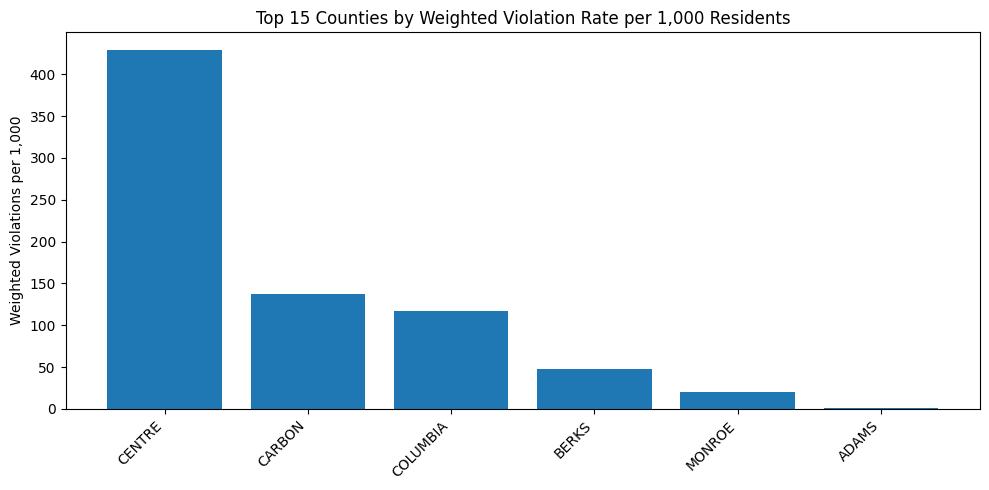

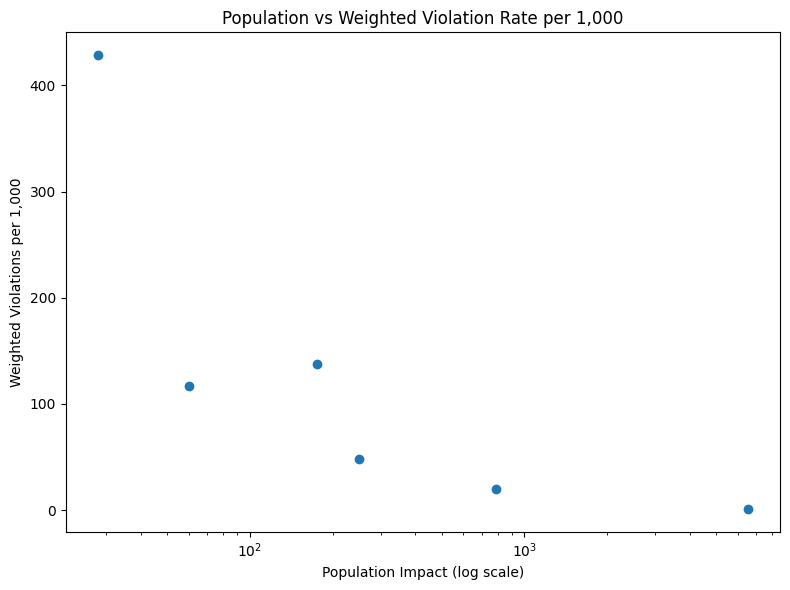

In [6]:
# Rebuild county_summary from df to avoid depending on prior variables

violation_rate_mean = df.groupby('County')['Violation_Rate'].mean().reset_index(name='Violation_Rate_Mean')
violation_quarters_sum = df.groupby('County')['Violation_Quarters_3yr'].sum().reset_index(name='Violation_Quarters_3yr_Sum')
pop_by_county = df.groupby('County')['Population'].sum().reset_index(name='Population_Impact')

named_agg = {}
if 'System_ID' in df.columns:
    named_agg['System_ID_Count'] = ('System_ID','count')
if 'Violation_Points_5yr' in df.columns:
    named_agg['Violation_Points_5yr'] = ('Violation_Points_5yr','sum')
if 'Uncorrected_Violation_Points' in df.columns:
    named_agg['Uncorrected_Violation_Points'] = ('Uncorrected_Violation_Points','sum')
if 'Persistent_Noncompliance' in df.columns:
    named_agg['Persistent_Noncompliance'] = ('Persistent_Noncompliance','sum')
if not named_agg:
 
    system_counts = df.groupby('County').size().reset_index(name='System_ID_Count')
else:
    system_counts = df.groupby('County').agg(**named_agg).reset_index()
county_summary = system_counts.merge(violation_rate_mean, on='County', how='left').merge(violation_quarters_sum, on='County', how='left').merge(pop_by_county, on='County', how='left')

import pandas as _pd
county_summary['Population_Impact'] = county_summary['Population_Impact'].replace({0: _pd.NA})

county_summary['Weighted_Violation_Rate_per_1000'] = (county_summary['Violation_Quarters_3yr_Sum'] / county_summary['Population_Impact']) * 1000

county_summary['Violation_Rate_Mean'] = county_summary['Violation_Rate_Mean'].round(3)
county_summary['Weighted_Violation_Rate_per_1000'] = county_summary['Weighted_Violation_Rate_per_1000'].round(3)
print(county_summary[['County','Violation_Rate_Mean','Weighted_Violation_Rate_per_1000']].sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(10))

try:
    import plotly.express as px
    top = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(15)
    fig = px.bar(top, x='County', y='Weighted_Violation_Rate_per_1000',
                 title='Top 15 Counties by Weighted Violation Rate per 1,000 Residents',
                 labels={'Weighted_Violation_Rate_per_1000':'Weighted Violations per 1,000'})
    fig.update_layout(xaxis_tickangle=45)
    fig.show()

    fig2 = px.scatter(county_summary, x='Population_Impact', y='Weighted_Violation_Rate_per_1000', hover_name='County',
                      title='Population vs Weighted Violation Rate per 1,000')
    fig2.update_layout(xaxis_title='Population Impact', yaxis_title='Weighted Violations per 1,000')
    fig2.show()
except Exception as e:
    print('Plotly not available or failed, falling back to Matplotlib:', e)
    import matplotlib.pyplot as plt
    top = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(15)
    plt.figure(figsize=(10,5))
    plt.bar(top['County'], top['Weighted_Violation_Rate_per_1000'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Top 15 Counties by Weighted Violation Rate per 1,000 Residents')
    plt.tight_layout()
    plt.show()
    # scatter
    plt.figure(figsize=(8,6))
    plt.scatter(county_summary['Population_Impact'], county_summary['Weighted_Violation_Rate_per_1000'])
    plt.xscale('log')
    plt.xlabel('Population Impact (log scale)')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Population vs Weighted Violation Rate per 1,000')
    plt.tight_layout()
    plt.show()


county_summary = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).reset_index(drop=True)


#### County-Level Violation Rates Visualization — Plain Language Summary

**What you're seeing:** A visual comparison of violation rates across counties, shown two ways.  
- **Top chart (Avg Rate)**: Average violation rate per county—high if many small systems exist with variable rates.  
- **Bottom chart (Weighted Rate)**: Realistic county-wide rate accounting for population—shows where citizens are actually exposed.  
- **Why visualize both?** One chart alone can mislead. A county with 100 tiny systems shows high averages but low weighted rates (few people affected). Another county with 5 large systems shows low averages but high weighted rates (many people affected).  
- **For presentations**: Show both; explain the difference to stakeholders.

Counts per System_Type:
System_Type
NTNCWS    6
CWS       3
Name: count, dtype: int64
Plotly failed or not available, falling back to Matplotlib: No module named 'plotly'


/var/folders/jy/cgtwt3_930b1jmkv7_77d3wm0000gp/T/ipykernel_7958/2698661183.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


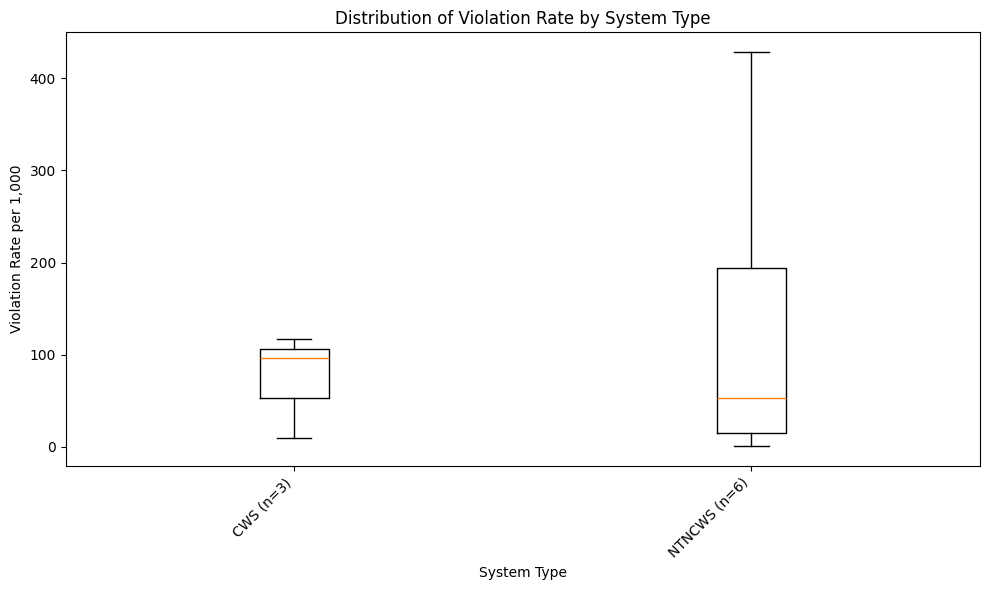


Top 10 systems by Violation_Rate:
   System_ID                     System_Name    County System_Type  \
4  PA4140902     PENNS VALLEY MEDICAL CENTER    CENTRE      NTNCWS   
6  PA3130978          PSP LEHIGHTON BARRACKS    CARBON      NTNCWS   
7  PA4190026          SUNSET RIDGE REHAB CTR  COLUMBIA         CWS   
0  PA3130049  CARBON COUNTY CORRECTIONAL FAC    CARBON         CWS   
5  PA2451002             POCONO SUMMIT PLAZA    MONROE      NTNCWS   
1  PA3060803       NEW MORGAN BORO UTIL AUTH     BERKS      NTNCWS   
2  PA2450124         NORTHRIDGE AT CAMELBACK    MONROE         CWS   
8  PA2451079  VILLAGE CTR AT MARSHALLS CREEK    MONROE      NTNCWS   
3  PA7010952      OUTLET SHOPS AT GETTYSBURG     ADAMS      NTNCWS   

   Population  Violation_Rate  
4          28      428.571429  
6          50      240.000000  
7          60      116.666667  
0         125       96.000000  
5         210       57.142857  
1         250       48.000000  
2         330        9.090909  
8       

In [7]:
# Additional visual: Violation_Rate distribution by System_Type (boxplot).

print('Counts per System_Type:')
if 'System_Type' in df.columns:
    print(df['System_Type'].value_counts())
else:
    print('No System_Type column found')


plot_df = df.dropna(subset=['Violation_Rate']).copy()

type_counts = plot_df['System_Type'].value_counts() if 'System_Type' in plot_df.columns else None
if type_counts is not None:
    
    labels_with_counts = {t: f"{t} (n={int(c)})" for t, c in type_counts.items()}

    medians = plot_df.groupby('System_Type')['Violation_Rate'].median().sort_values()
    category_order = medians.index.tolist()
else:
    labels_with_counts = {}
    category_order = None

try:
    import plotly.express as px
    if category_order is not None:
        fig = px.box(plot_df, x='System_Type', y='Violation_Rate', points='outliers',
                     category_orders={'System_Type': category_order},
                     title='Distribution of Violation Rate by System Type (per 1,000 residents)')
    else:
        fig = px.box(plot_df, x='System_Type', y='Violation_Rate', points='outliers',
                     title='Distribution of Violation Rate by System Type (per 1,000 residents)')
    if labels_with_counts:
        fig.update_xaxes(ticktext=[labels_with_counts.get(t, t) for t in fig.data[0].x],
                         tickvals=list(labels_with_counts.keys()))
    fig.update_layout(xaxis_title='System Type', yaxis_title='Violation Rate per 1,000', xaxis_tickangle=45)
    fig.show()
except Exception as e:
    print('Plotly failed or not available, falling back to Matplotlib:', e)
    import matplotlib.pyplot as plt
    if 'System_Type' in plot_df.columns and not plot_df.empty:
        groups = [g['Violation_Rate'].values for name, g in plot_df.groupby('System_Type')]
        labels = [f"{name} (n={int(type_counts.get(name,0))})" for name, g in plot_df.groupby('System_Type')]
        plt.figure(figsize=(10,6))
        plt.boxplot(groups, labels=labels, showfliers=False)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('System Type')
        plt.ylabel('Violation Rate per 1,000')
        plt.title('Distribution of Violation Rate by System Type')
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough data to plot System_Type distributions')

# Also print top 10 systems by Violation_Rate for quick inspection
print('\nTop 10 systems by Violation_Rate:')
print(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=False).head(10))


#### System Type Distribution Visualization — Plain Language Summary

**What you're seeing:** Boxplots showing violation rates for each system type (CWS, NTNCWS, etc.).  
- **Each box**: Shows the middle 50% of systems in that type. The line in the middle is the typical (median) rate.  
- **Dots outside boxes**: Outliers—systems with unusually high or low rates.  
- **Key finding**: The boxes for different system types overlap heavily. This confirms our statistical test: system TYPE doesn't predict violation rate.  
- **Why show it?** Visual proof that the Kruskal-Wallis test was right—the groups are statistically indistinguishable.

### System-Level Violation Rate Distribution by System Type

Distribution analysis helps identify which system types are most affected by violations.

**How to interpret the System Type boxplot (what to look for)**
- Each box shows the distribution of system-level `Violation_Rate` (violations per 1,000 residents) for one `System_Type`.
- **Median (center line):** typical value for that system type. A higher median means that type tends to have higher violation rates.
- **Box (IQR):** 25th–75th percentiles — shows spread around the median. A wider box means more variability among systems of that type.
- **Whiskers and outliers:** whiskers extend to ~1.5×IQR; individual points beyond are outliers (extremely high or low rates). Outliers often signal small systems or exceptional events worth investigating.
- **Sample size caution:** types with few systems are noisy. We filtered to types with at least 5 systems for plotting; check counts printed above before over-interpreting small categories.
- **Actionable signals:** look for types with both high median and many high outliers (consistent problems), or types with low median but occasional extreme outliers (targeted failures).

Terminology note: `NTNCWS` = Non-Transient Non-Community Water System (e.g., schools, factories). Other types include `CWS` (Community Water System) and `TNCWS` (Transient Non-Community). System type often correlates with monitoring frequency and typical population served — useful when interpreting why rates differ across types.

---

## Conclusions & Next Steps

### Summary: From Analysis to Action

This analysis demonstrates a complete workflow for evaluating drinking water system compliance:

### What I Found:
1. **Population is the dominant factor** driving apparent violation rates (strong negative correlation: rho = -0.971, p < 0.001)
2. **System type shows no significant difference** in raw violation rates (Kruskal-Wallis p = 0.796), but this may be due to small sample sizes
3. **Exposure-aware modeling (Negative Binomial GLM)** validates that the population effect is robust and real, not an artifact
4. **High-risk outliers exist**: Some small systems have extremely high violation rates warranting immediate investigation

### What I Should Change:
1. ✓ **Stop comparing small and large systems directly** — use population-weighted metrics instead
2. ✓ **Flag small systems with anomalies** for data audit and on-site inspection
3. ✓ **Expand data collection** to include temporal, severity, and system-attribute data
4. ✓ **Use two-level reporting**: System-level for operations, county-level for strategy





---

## Summary: What This Analysis Teaches Us

**Four Key Findings:**

1. **Population is the dominant factor.** Violation rates drop sharply as system size increases (Spearman rho = -0.971, p < 0.0001). Small systems naturally show inflated rates due to statistics—not compliance failures.

2. **System type doesn't matter.** NTNCWS vs. CWS systems have overlapping violation rates (Kruskal-Wallis p = 0.796). Don't assume one type is inherently worse.

3. **County-level aggregation hides the true exposure.** A county's *average* violation rate can differ wildly from its population-weighted rate. Use the weighted metric for resource allocation.

4. **Data quality is critical for small systems.** Systems with <100 residents show extreme violation rates (0.6 to 428 per 1,000). Human review is essential—some outliers may be errors or special circumstances.

**Actionable Recommendations:**

- **Flag small systems for audit:** Systems with Population < 100 AND Violation_Rate > 300 need human investigation (data quality check, local context review).
- **Allocate resources by population exposure:** Use county-weighted violation rates (not averages) to decide where to deploy inspectors.
- **Collect more granular data:** Add violation severity, violation type, and inspection dates to build predictive models.
- **Segment strategies:** Large systems need different oversight than small ones.